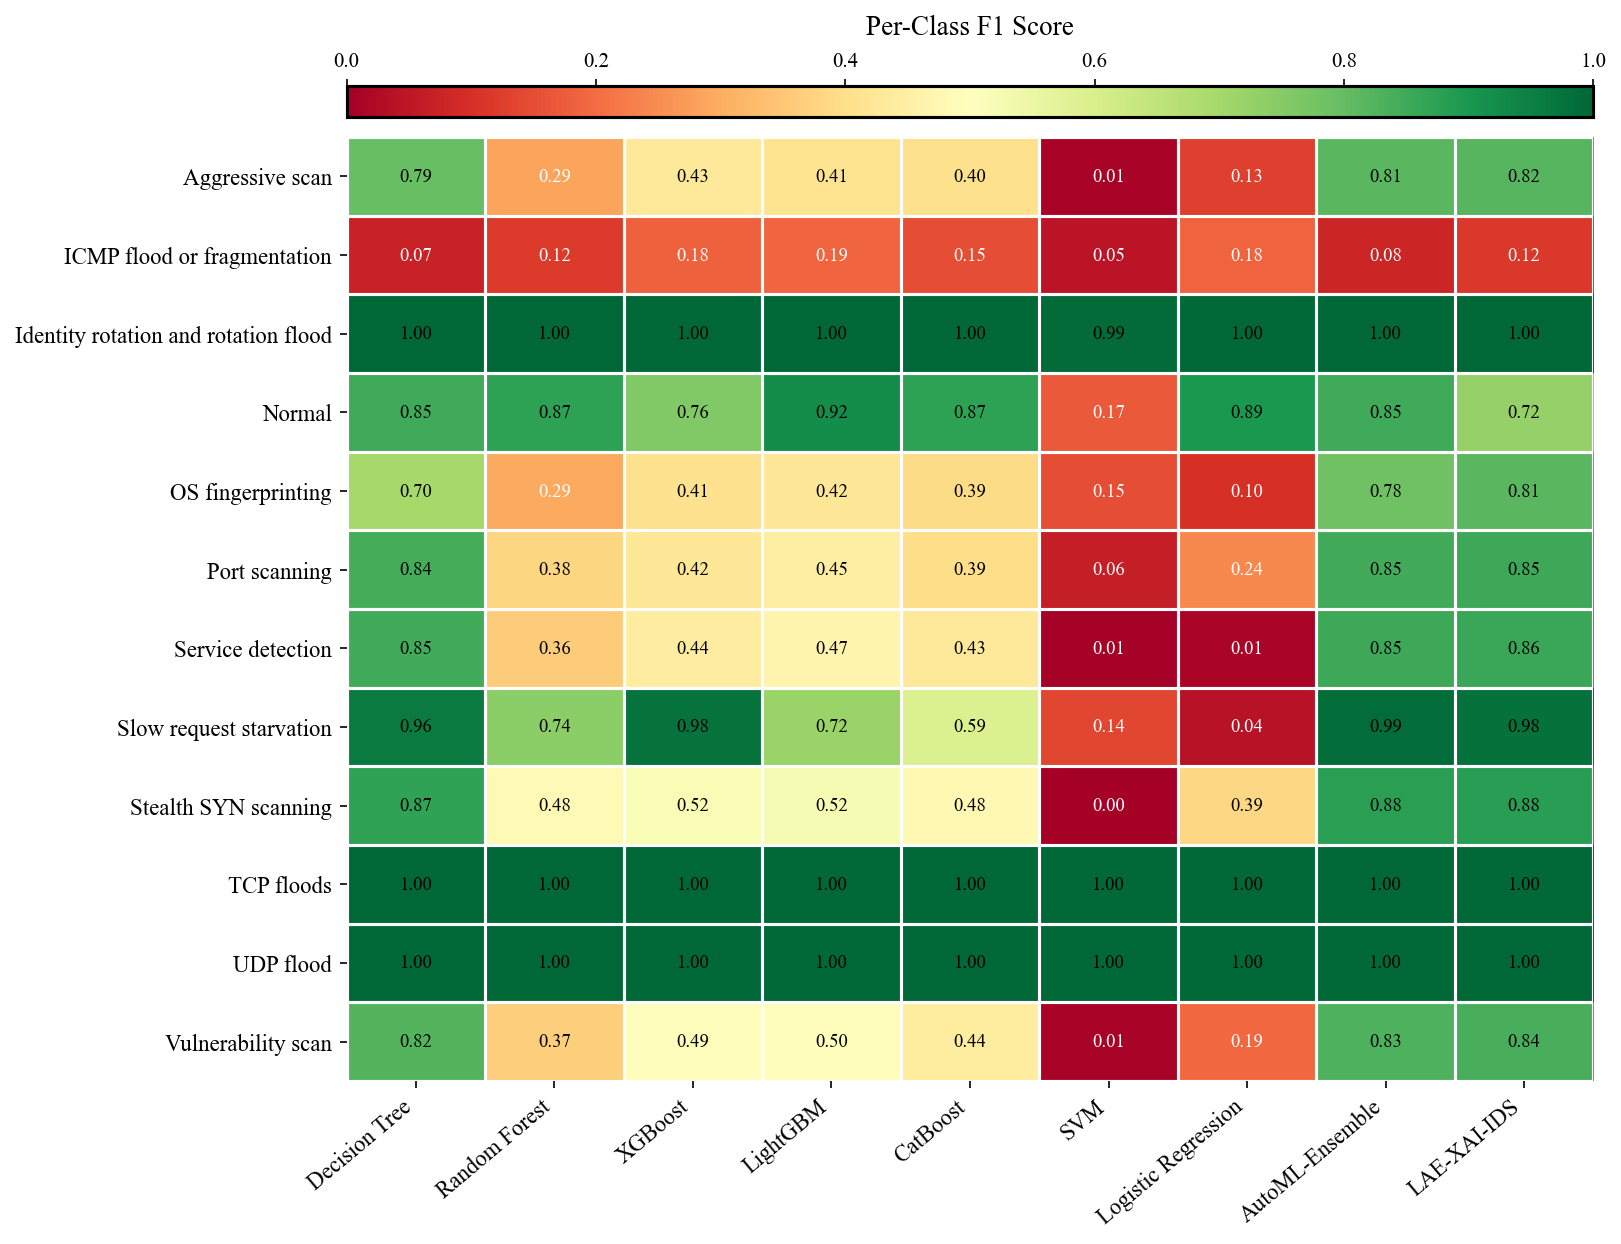

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 13, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'axes.linewidth': 1.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'mathtext.fontset': 'stix',
})

classes = ['Aggressive scan', 'ICMP flood or fragmentation', 'Identity rotation and rotation flood',
           'Normal', 'OS fingerprinting', 'Port scanning', 'Service detection',
           'Slow request starvation', 'Stealth SYN scanning', 'TCP floods',
           'UDP flood', 'Vulnerability scan']

models = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost',
          'SVM', 'Logistic Regression', 'AutoML-Ensemble', 'LAE-XAI-IDS']

data = np.array([
    [0.7940445558707748, 0.2853937536310275, 0.4323321073423239, 0.4113320991218982, 0.4048071987196908, 0.01122888533952858, 0.12796701326640372, 0.8140143782728322, 0.8190930366052899],
    [0.07239819004524888, 0.12030075187969924, 0.1797752808988764, 0.19047619047619047, 0.1509433962264151, 0.045454545454545456, 0.1839080459770115, 0.08040201005025126, 0.11678832116788321],
    [0.9998760239941255, 0.9998569562190668, 0.9998569562190668, 0.9998569562190668, 0.9983244478293983, 0.9915092377224334, 0.9973559567061688, 0.9998569562190668, 0.9998569562190668],
    [0.85, 0.8717948717948718, 0.7555555555555555, 0.918918918918919, 0.8717948717948718, 0.16853932584269662, 0.8947368421052632, 0.85, 0.723404255319149],
    [0.6973673463831641, 0.2930021522889884, 0.40833802521833634, 0.4225388467296474, 0.3919649997647834, 0.15041480825757833, 0.0998946497102867, 0.7836311168416529, 0.8144869342523358],
    [0.8400091838191036, 0.38188596238817807, 0.42458911945850775, 0.44750074746541274, 0.3946950948664255, 0.06305113280568302, 0.24226729966911237, 0.8451897142996619, 0.8516663115926592],
    [0.8464746421629263, 0.36194438548078967, 0.4430868537836436, 0.4675482166885393, 0.4281955145844799, 0.0071123513297374555, 0.012089170258620689, 0.8526567358511576, 0.8587638760308819],
    [0.959954233409611, 0.738556338028169, 0.9755813953488373, 0.7165591397849462, 0.5918871252204585, 0.13877551020408163, 0.04050929494096248, 0.9870588235294118, 0.9772594752186589],
    [0.8703869010923976, 0.4829523558404154, 0.5165720006093447, 0.5210350639479163, 0.47778530969587646, 0.0, 0.38560068199138037, 0.8779822901242437, 0.8813707397518454],
    [0.9996741090001386, 0.9998578328877608, 0.9998370302048911, 0.9998543659022032, 0.9992783240463815, 0.9967615926981046, 0.9989309935512533, 0.9998439629255911, 0.9998474298870981],
    [0.9995378927911276, 0.9995378927911276, 0.9992295839753467, 0.999383762132183, 0.9995378927911276, 0.9995378927911276, 0.9993839519482519, 0.999383762132183, 0.9994608333975198],
    [0.8240719934084513, 0.3650958732594889, 0.49300939498611557, 0.4952807427280974, 0.441222085842872, 0.008436275986742995, 0.19420136844456176, 0.8294061807826179, 0.8360050356693244],
])

fig, ax = plt.subplots(figsize=(11, 8.5))
cmap = plt.cm.RdYlGn
im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(models))); ax.set_xticklabels(models, rotation=40, ha='right', fontsize=11)
ax.set_yticks(np.arange(len(classes))); ax.set_yticklabels(classes, fontsize=11)

ax.set_xticks(np.arange(-0.5, len(models), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', length=0)

for i in range(len(classes)):
    for j in range(len(models)):
        val = data[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                 color='black' if 0.3 < val else 'white')

for spine in ax.spines.values(): spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', location='top',
                     pad=0.02, fraction=0.045, aspect=40)
cbar.set_label('Per-Class F1 Score', fontsize=13, labelpad=8)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', bbox_inches='tight')
plt.show()